In [1]:
import numpy as np
import os

# ✅ 改成你解壓後的檔案位置
npy_path = r"C:\Users\User\Documents\465 HW\project\AAAAAA\STO_final_aligned.npy"

assert os.path.exists(npy_path), f"找不到檔案：{npy_path}"

D = np.load(npy_path, mmap_mode="r")  # memmap：不會整包載入 RAM
print("Loaded:", npy_path)
print("shape:", D.shape, "dtype:", D.dtype)

Ny, Nx, Ky, Kx = D.shape
print("Scan grid (Ny,Nx) =", (Ny, Nx), " | DP size (Ky,Kx) =", (Ky, Kx))

Loaded: C:\Users\User\Documents\465 HW\project\AAAAAA\STO_final_aligned.npy
shape: (256, 256, 128, 128) dtype: float32
Scan grid (Ny,Nx) = (256, 256)  | DP size (Ky,Kx) = (128, 128)


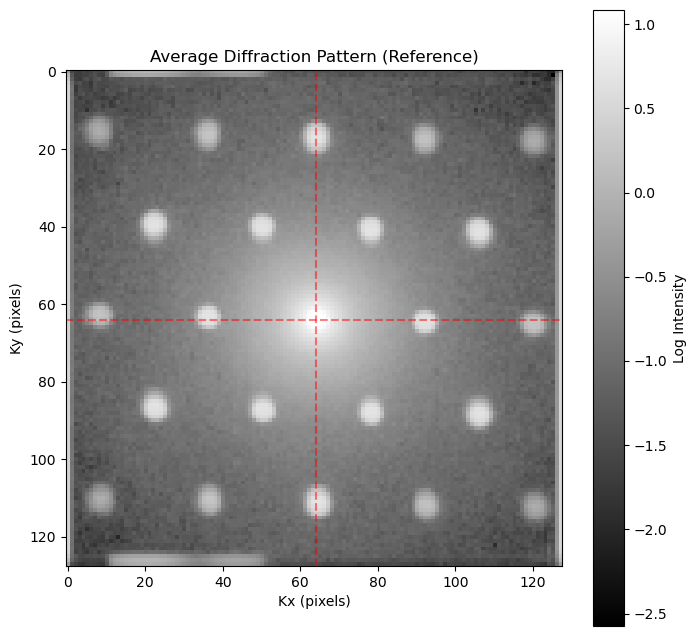

In [2]:
import matplotlib.pyplot as plt

# 1. 計算平均繞射圖樣 (Average Diffraction Pattern)
# 由於檔案很大，我們取實空間中一個沒有明顯缺陷的區域來做平均，作為「參考晶格」
# 假設你取左上角 50x50 的區域作為無應變的 Reference (你可以根據你的樣本修改範圍)
ref_region = D[0:50, 0:50, :, :]
mean_dp = np.mean(ref_region, axis=(0, 1))

# 2. 視覺化平均繞射圖樣，尋找你要追蹤的斑點
plt.figure(figsize=(8, 8))
# 使用對數尺度 (log scale) 來顯示，這樣弱的繞射斑點才看得清楚
plt.imshow(np.log10(mean_dp + 1e-5), cmap='gray', origin='upper')
plt.title("Average Diffraction Pattern (Reference)")
plt.xlabel("Kx (pixels)")
plt.ylabel("Ky (pixels)")

# 畫出中心點 (透射斑點 / Center Beam) 幫助定位
plt.axvline(x=64, color='r', linestyle='--', alpha=0.5) # 128 的一半
plt.axhline(y=64, color='r', linestyle='--', alpha=0.5)

plt.colorbar(label='Log Intensity')
plt.show()

In [3]:
import scipy.ndimage as ndimage
import time

# 1. 設定我們要追蹤的兩個參考斑點大約位置 (Ky_center, Kx_center)
# 注意：Numpy 陣列的索引是 [y, x]，所以 Ky 放前面
spot1_guess = (64, 92) 
spot2_guess = (88, 78) 

# 設定裁切區域 (ROI) 的半徑 (Pixels)。設定 8 代表框出 16x16 的視窗
R = 8 

# 準備空陣列來儲存追蹤到的精確座標
# shape=(Ny, Nx, 2)，最後一維度存 (Kx, Ky)
g1_map = np.zeros((Ny, Nx, 2))
g2_map = np.zeros((Ny, Nx, 2))

print("開始進行繞射斑點質心追蹤 (這可能需要 1~3 分鐘，請稍候)...")
start_time = time.time()

# 針對每一個實空間的 pixel 進行迴圈
for y in range(Ny):
    for x in range(Nx):
        # 讀取該點的 2D 繞射圖樣
        dp = D[y, x, :, :]
        
        # --- 追蹤 Spot 1 ---
        sy, sx = spot1_guess
        roi1 = dp[sy-R : sy+R, sx-R : sx+R].copy()
        # 扣除背景雜訊，讓質心計算更精準 (很重要！)
        roi1 = roi1 - np.min(roi1) 
        # 計算質心 (相對於 ROI 左上角)
        com_y1, com_x1 = ndimage.center_of_mass(roi1)
        # 換算回整張圖的絕對座標 (存入: Kx, Ky)
        g1_map[y, x, 0] = sx - R + com_x1
        g1_map[y, x, 1] = sy - R + com_y1

        # --- 追蹤 Spot 2 ---
        sy, sx = spot2_guess
        roi2 = dp[sy-R : sy+R, sx-R : sx+R].copy()
        roi2 = roi2 - np.min(roi2)
        com_y2, com_x2 = ndimage.center_of_mass(roi2)
        g2_map[y, x, 0] = sx - R + com_x2
        g2_map[y, x, 1] = sy - R + com_y2
        
    # 每 50 行印出一次進度
    if (y + 1) % 50 == 0:
        print(f"進度: {y + 1}/{Ny} 行完成...")

print(f"追蹤完成！總耗時: {time.time() - start_time:.2f} 秒")

開始進行繞射斑點質心追蹤 (這可能需要 1~3 分鐘，請稍候)...
進度: 50/256 行完成...
進度: 100/256 行完成...
進度: 150/256 行完成...
進度: 200/256 行完成...


C:\Users\User\miniconda3\envs\mse465\Lib\site-packages\scipy\ndimage\_measurements.py:1550: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / normalizer


進度: 250/256 行完成...
追蹤完成！總耗時: 6.32 秒


--- 診斷資訊 ---
g1_map 包含壞點 (NaN) 嗎? True
成功救回的 Reference Spot 1 (dy, dx): [91.3334332  64.01674409]
成功救回的 Reference Spot 2 (dy, dx): [77.52149418 87.0662534 ]
重新計算應變張量中...
計算完成！開始繪圖...


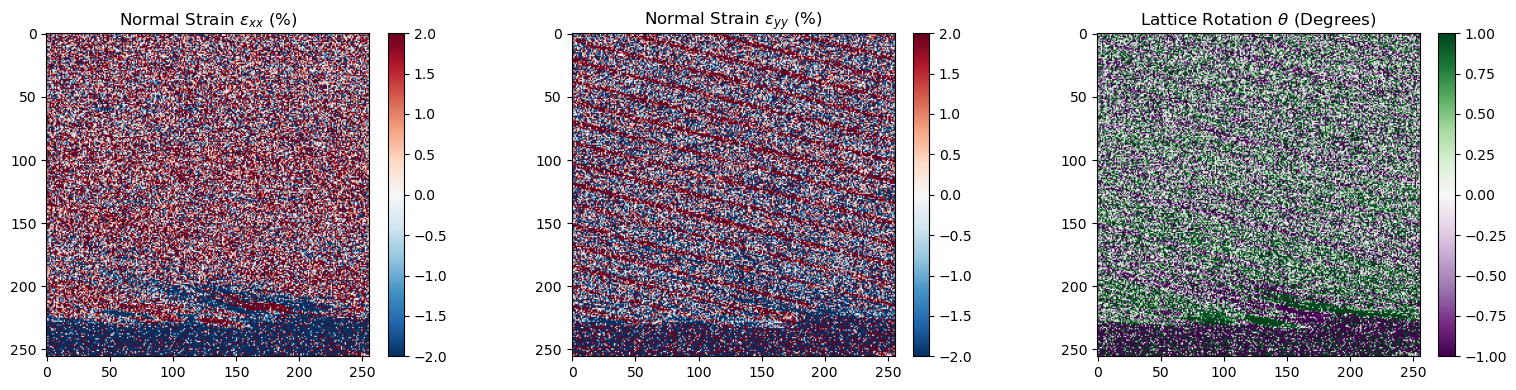

In [4]:
# 重新修正的 Cell 2 & 3: 防呆與抗 NaN 版本
import numpy as np
import matplotlib.pyplot as plt

print("--- 診斷資訊 ---")
print("g1_map 包含壞點 (NaN) 嗎?", np.isnan(g1_map).any())

# 1. 萃取參考向量 (使用 nanmean 忽略所有 NaN 壞點)
g1_ref = np.nanmean(g1_map, axis=(0, 1))
g2_ref = np.nanmean(g2_map, axis=(0, 1))

print(f"成功救回的 Reference Spot 1 (dy, dx): {g1_ref}")
print(f"成功救回的 Reference Spot 2 (dy, dx): {g2_ref}")

# 建立參考矩陣 B0
B0 = np.array([[g1_ref[0], g2_ref[0]], 
               [g1_ref[1], g2_ref[1]]])
B0_inv = np.linalg.inv(B0)

# 準備空陣列
strain_xx = np.zeros((Ny, Nx))
strain_yy = np.zeros((Ny, Nx))
rotation  = np.zeros((Ny, Nx))

print("重新計算應變張量中...")

for y in range(Ny):
    for x in range(Nx):
        # 防呆機制：如果該點的追蹤結果是 NaN，就直接賦予 NaN 並跳過，保護其他正常點
        if np.isnan(g1_map[y, x, 0]) or np.isnan(g2_map[y, x, 0]):
            strain_xx[y, x] = np.nan
            strain_yy[y, x] = np.nan
            rotation[y, x] = np.nan
            continue
            
        B = np.array([[g1_map[y, x, 0], g2_map[y, x, 0]], 
                      [g1_map[y, x, 1], g2_map[y, x, 1]]])
        
        # 形變計算
        I_minus_beta_T = np.dot(B, B0_inv)
        beta_T = np.eye(2) - I_minus_beta_T
        beta = beta_T.T
        
        strain_xx[y, x] = beta[0, 0]
        strain_yy[y, x] = beta[1, 1]
        rotation[y, x] = 0.5 * (beta[0, 1] - beta[1, 0])

# 轉成百分比與度數
strain_xx_pct = strain_xx * 100
strain_yy_pct = strain_yy * 100
rotation_deg = np.degrees(rotation)

print("計算完成！開始繪圖...")

# --- 繪圖 (Cell 3 功能合併) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 設定 Matplotlib 遇到 NaN (壞點) 時顯示為灰色 (或其他明顯背景色)
cmap_strain = plt.get_cmap('RdBu_r').copy()
cmap_strain.set_bad(color='lightgray')

cmap_rot = plt.get_cmap('PRGn').copy()
cmap_rot.set_bad(color='lightgray')

vmin, vmax = -2.0, 2.0 

# 圖 1: Strain xx
im0 = axes[0].imshow(strain_xx_pct, cmap=cmap_strain, vmin=vmin, vmax=vmax, origin='upper')
axes[0].set_title(r"Normal Strain $\epsilon_{xx}$ (%)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# 圖 2: Strain yy
im1 = axes[1].imshow(strain_yy_pct, cmap=cmap_strain, vmin=vmin, vmax=vmax, origin='upper')
axes[1].set_title(r"Normal Strain $\epsilon_{yy}$ (%)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# 圖 3: Rotation
im2 = axes[2].imshow(rotation_deg, cmap=cmap_rot, vmin=-1.0, vmax=1.0, origin='upper')
axes[2].set_title(r"Lattice Rotation $\theta$ (Degrees)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

重新校準的 Reference Spot 1: [91.0442171  64.12972939]
重新校準的 Reference Spot 2: [77.46799507 87.03218394]


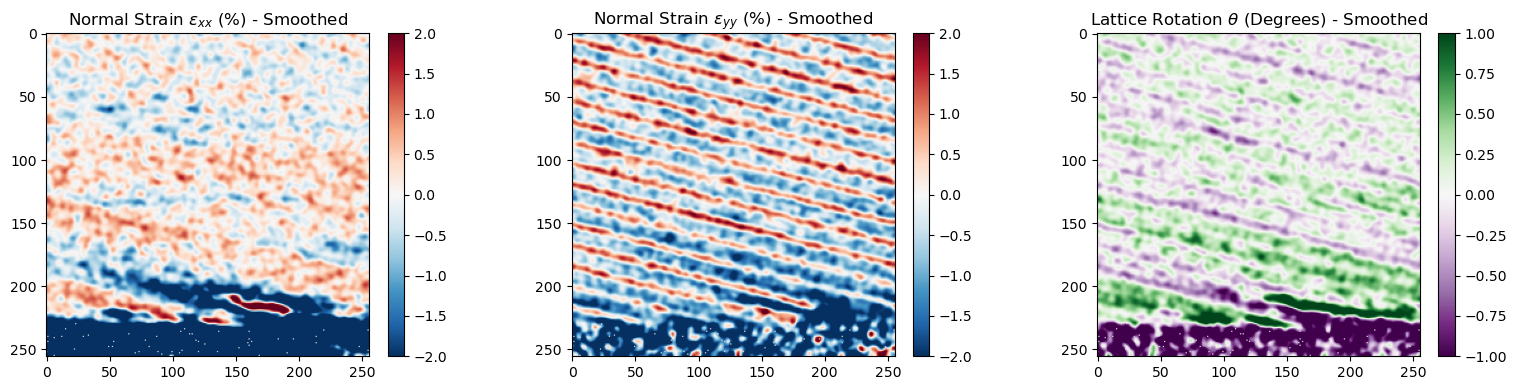

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# --- 1. 選擇乾淨的「參考區域 (Reference ROI)」 ---
# 從你的圖來看，y=220 以上是邊界區。
# 我們選擇左下角 (y=0~100, x=0~100) 這個看起來相對均勻的區域作為 0% 應變的基準。
ref_y_start, ref_y_end = 0, 100
ref_x_start, ref_x_end = 0, 100

g1_ref = np.nanmean(g1_map[ref_y_start:ref_y_end, ref_x_start:ref_x_end], axis=(0, 1))
g2_ref = np.nanmean(g2_map[ref_y_start:ref_y_end, ref_x_start:ref_x_end], axis=(0, 1))

print(f"重新校準的 Reference Spot 1: {g1_ref}")
print(f"重新校準的 Reference Spot 2: {g2_ref}")

B0 = np.array([[g1_ref[0], g2_ref[0]], 
               [g1_ref[1], g2_ref[1]]])
B0_inv = np.linalg.inv(B0)

# --- 2. 重新計算應變 (只做矩陣運算，速度極快) ---
strain_xx = np.zeros((Ny, Nx))
strain_yy = np.zeros((Ny, Nx))
rotation  = np.zeros((Ny, Nx))

for y in range(Ny):
    for x in range(Nx):
        if np.isnan(g1_map[y, x, 0]) or np.isnan(g2_map[y, x, 0]):
            strain_xx[y, x] = np.nan
            strain_yy[y, x] = np.nan
            rotation[y, x] = np.nan
            continue
            
        B = np.array([[g1_map[y, x, 0], g2_map[y, x, 0]], 
                      [g1_map[y, x, 1], g2_map[y, x, 1]]])
        
        I_minus_beta_T = np.dot(B, B0_inv)
        beta_T = np.eye(2) - I_minus_beta_T
        beta = beta_T.T
        
        strain_xx[y, x] = beta[0, 0]
        strain_yy[y, x] = beta[1, 1]
        rotation[y, x] = 0.5 * (beta[0, 1] - beta[1, 0])

strain_xx_pct = strain_xx * 100
strain_yy_pct = strain_yy * 100
rotation_deg = np.degrees(rotation)

# --- 3. 物理降噪 (Gaussian Filter 平滑化) ---
# sigma 值控制平滑程度，通常設 1.5 ~ 3 之間。這裡設 2.0。
smooth_sigma = 2.0

# 暫時將 NaN 替換為 0 以進行卷積平滑
mask = np.isnan(strain_xx_pct)
strain_xx_clean = np.where(mask, 0, strain_xx_pct)
strain_yy_clean = np.where(mask, 0, strain_yy_pct)
rotation_clean  = np.where(mask, 0, rotation_deg)

strain_xx_smooth = gaussian_filter(strain_xx_clean, sigma=smooth_sigma)
strain_yy_smooth = gaussian_filter(strain_yy_clean, sigma=smooth_sigma)
rotation_smooth  = gaussian_filter(rotation_clean, sigma=smooth_sigma)

# 平滑完畢後，把真空區/壞點的 NaN 蓋回去
strain_xx_smooth[mask] = np.nan
strain_yy_smooth[mask] = np.nan
rotation_smooth[mask] = np.nan

# --- 4. 繪製最終平滑版的應變圖 ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cmap_strain = plt.get_cmap('RdBu_r').copy()
cmap_strain.set_bad(color='lightgray') # 壞點顯示為淺灰色

cmap_rot = plt.get_cmap('PRGn').copy()
cmap_rot.set_bad(color='lightgray')

vmin, vmax = -2.0, 2.0 

im0 = axes[0].imshow(strain_xx_smooth, cmap=cmap_strain, vmin=vmin, vmax=vmax, origin='upper')
axes[0].set_title(r"Normal Strain $\epsilon_{xx}$ (%) - Smoothed")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(strain_yy_smooth, cmap=cmap_strain, vmin=vmin, vmax=vmax, origin='upper')
axes[1].set_title(r"Normal Strain $\epsilon_{yy}$ (%) - Smoothed")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(rotation_smooth, cmap=cmap_rot, vmin=-1.0, vmax=1.0, origin='upper')
axes[2].set_title(r"Lattice Rotation $\theta$ (Degrees) - Smoothed")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

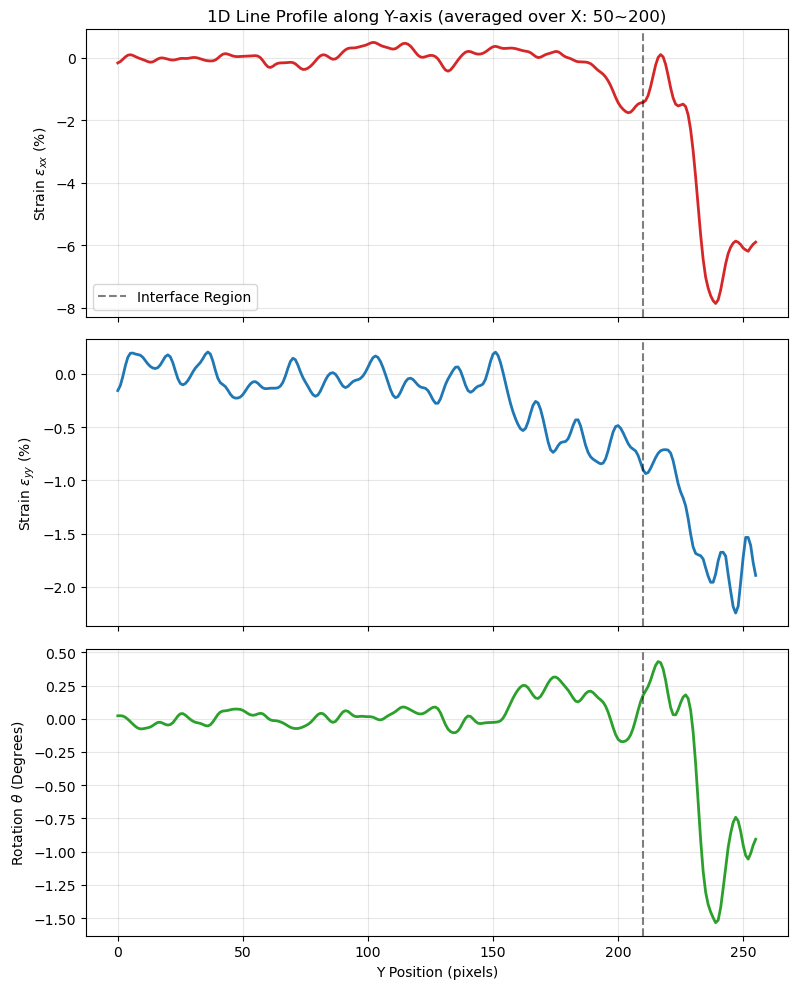

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定義 1D 萃取範圍 ---
# 我們沿著 Y 軸畫線，並在 X 軸方向取一段範圍做平均以降低雜訊
# 從你的圖來看，x=50 到 x=200 的中間區域數據滿完整的
x_start, x_end = 50, 200

# 沿著 X 軸 (axis=1) 取平均，得到長度為 Ny (256) 的 1D 陣列
profile_xx = np.nanmean(strain_xx_smooth[:, x_start:x_end], axis=1)
profile_yy = np.nanmean(strain_yy_smooth[:, x_start:x_end], axis=1)
profile_rot = np.nanmean(rotation_smooth[:, x_start:x_end], axis=1)

y_axis = np.arange(Ny) # Y 軸像素座標 (0~255)

# --- 2. 繪製 1D 剖面線 ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# 標示介面大約位置的輔助線
interface_y = 210 

# (A) Strain xx
axes[0].plot(y_axis, profile_xx, color='tab:red', linewidth=2)
axes[0].set_ylabel(r"Strain $\epsilon_{xx}$ (%)")
axes[0].set_title(f"1D Line Profile along Y-axis (averaged over X: {x_start}~{x_end})")
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=interface_y, color='black', linestyle='--', alpha=0.5, label='Interface Region')
axes[0].legend()

# (B) Strain yy
axes[1].plot(y_axis, profile_yy, color='tab:blue', linewidth=2)
axes[1].set_ylabel(r"Strain $\epsilon_{yy}$ (%)")
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=interface_y, color='black', linestyle='--', alpha=0.5)

# (C) Rotation
axes[2].plot(y_axis, profile_rot, color='tab:green', linewidth=2)
axes[2].set_xlabel("Y Position (pixels)")
axes[2].set_ylabel(r"Rotation $\theta$ (Degrees)")
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=interface_y, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

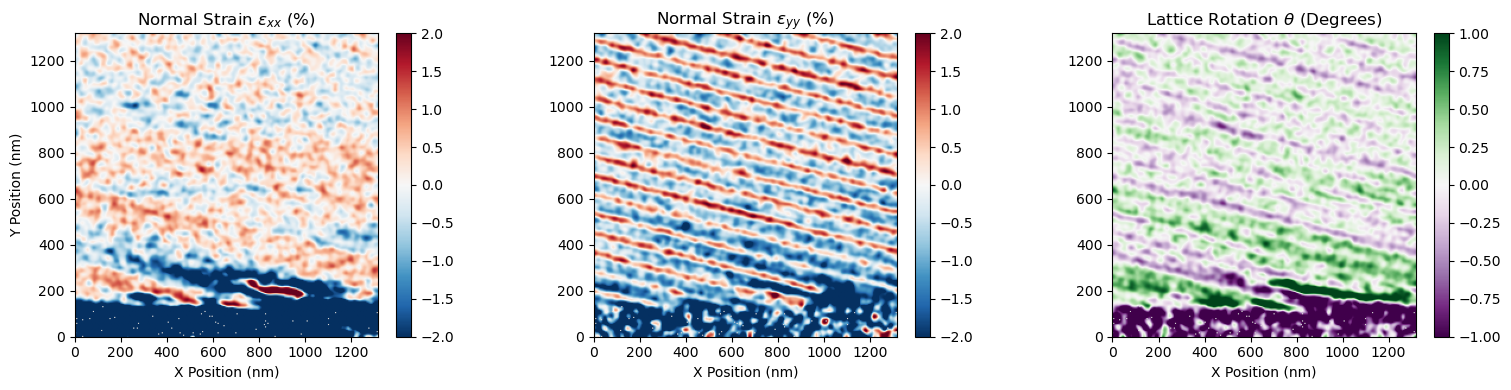

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 設定真實物理尺寸 ---
pixel_size_nm = 5.152 
# 計算整張圖的物理邊界 [x_min, x_max, y_min, y_max]
extent_nm = [0, Nx * pixel_size_nm, 0, Ny * pixel_size_nm]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cmap_strain = plt.get_cmap('RdBu_r').copy()
cmap_strain.set_bad(color='lightgray')

cmap_rot = plt.get_cmap('PRGn').copy()
cmap_rot.set_bad(color='lightgray')

vmin, vmax = -2.0, 2.0 

# --- 2. 繪圖並套用 extent ---
# (A) Strain xx
im0 = axes[0].imshow(strain_xx_smooth, cmap=cmap_strain, vmin=vmin, vmax=vmax, origin='upper', extent=extent_nm)
axes[0].set_title(r"Normal Strain $\epsilon_{xx}$ (%)")
axes[0].set_xlabel("X Position (nm)")
axes[0].set_ylabel("Y Position (nm)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# (B) Strain yy
im1 = axes[1].imshow(strain_yy_smooth, cmap=cmap_strain, vmin=vmin, vmax=vmax, origin='upper', extent=extent_nm)
axes[1].set_title(r"Normal Strain $\epsilon_{yy}$ (%)")
axes[1].set_xlabel("X Position (nm)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# (C) Rotation
im2 = axes[2].imshow(rotation_smooth, cmap=cmap_rot, vmin=-1.0, vmax=1.0, origin='upper', extent=extent_nm)
axes[2].set_title(r"Lattice Rotation $\theta$ (Degrees)")
axes[2].set_xlabel("X Position (nm)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

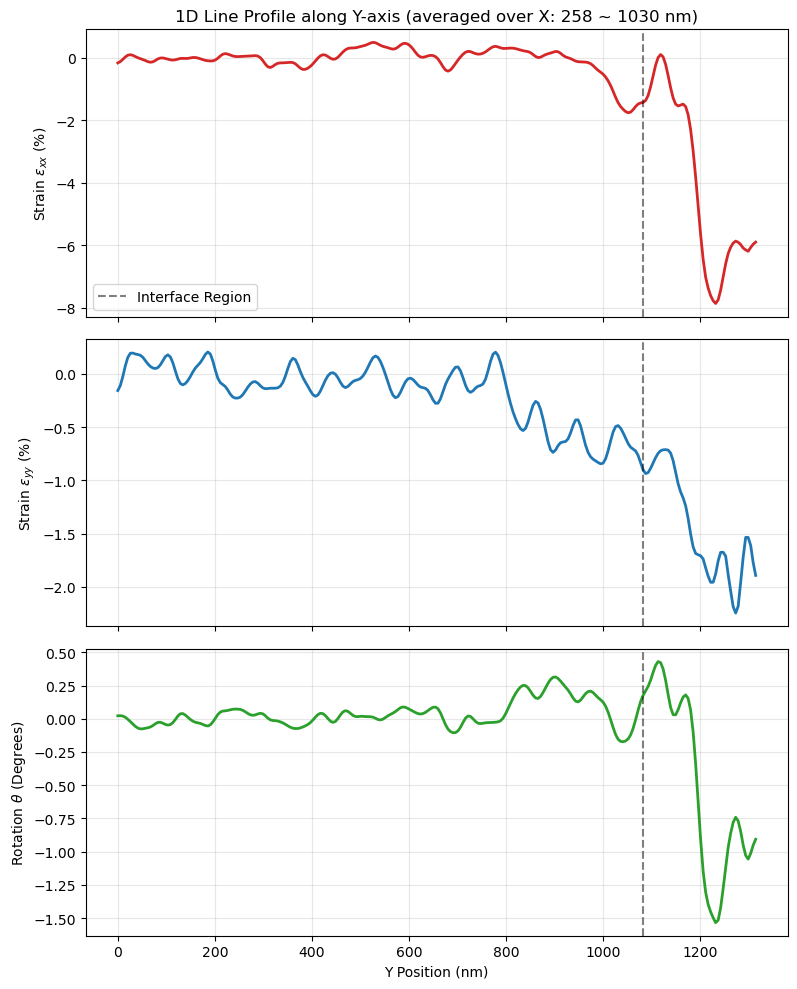

In [8]:
# --- 1. 換算 Y 軸為奈米 ---
y_axis_nm = np.arange(Ny) * pixel_size_nm
interface_y_nm = 210 * pixel_size_nm  # 將介面位置換算成 nm

# 同步換算標題上標示的平均範圍
x_start_nm = x_start * pixel_size_nm
x_end_nm = x_end * pixel_size_nm

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# (A) Strain xx
axes[0].plot(y_axis_nm, profile_xx, color='tab:red', linewidth=2)
axes[0].set_ylabel(r"Strain $\epsilon_{xx}$ (%)")
axes[0].set_title(f"1D Line Profile along Y-axis (averaged over X: {x_start_nm:.0f} ~ {x_end_nm:.0f} nm)")
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=interface_y_nm, color='black', linestyle='--', alpha=0.5, label='Interface Region')
axes[0].legend()

# (B) Strain yy
axes[1].plot(y_axis_nm, profile_yy, color='tab:blue', linewidth=2)
axes[1].set_ylabel(r"Strain $\epsilon_{yy}$ (%)")
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=interface_y_nm, color='black', linestyle='--', alpha=0.5)

# (C) Rotation
axes[2].plot(y_axis_nm, profile_rot, color='tab:green', linewidth=2)
axes[2].set_xlabel("Y Position (nm)")  # 注意這裡改成了奈米
axes[2].set_ylabel(r"Rotation $\theta$ (Degrees)")
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=interface_y_nm, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()